In [18]:
from pathlib import Path
import json
import joblib

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

PROJECT_ROOT = Path("..").resolve()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = PROCESSED_DIR / "manual_labels_with_layout_features_v1.csv"

In [19]:
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print(df.columns.tolist())

df.head()

Shape: (175, 35)
['document_name', 'page_number', 'char_count', 'word_count', 'avg_word_length', 'printable_char_ratio', 'whitespace_ratio', 'alphabetic_ratio', 'digit_ratio', 'symbol_ratio', 'text_block_count', 'image_count', 'page_width', 'page_height', 'page_area', 'chars_per_page_area', 'words_per_page_area', 'text_preview', 'label', 'layout_page_width', 'layout_page_height', 'layout_page_area', 'layout_text_block_count', 'layout_image_count', 'total_text_area', 'avg_text_block_area', 'largest_text_block_area', 'total_image_area', 'avg_image_area', 'largest_image_area', 'text_area_ratio', 'image_area_ratio', 'largest_image_area_ratio', 'largest_text_block_ratio', 'text_to_image_area_ratio']


,document_name,page_number,char_count,word_count,avg_word_length,printable_char_ratio,whitespace_ratio,alphabetic_ratio,digit_ratio,symbol_ratio,...,avg_text_block_area,largest_text_block_area,total_image_area,avg_image_area,largest_image_area,text_area_ratio,image_area_ratio,largest_image_area_ratio,largest_text_block_ratio,text_to_image_area_ratio
0,anime_ir_report_80.pdf,1,2182,304,5.953947,0.999542,0.129239,0.807058,0.021082,0.042621,...,3220.193826,6583.045756,0.0,0.0,0.0,0.237862,0.0,0.0,0.013142,0.237862
1,anime_ir_report_80.pdf,2,2032,244,6.102459,0.973917,0.183563,0.701772,0.028543,0.086122,...,4636.197420,61616.470045,0.0,0.0,0.0,0.259156,0.0,0.0,0.123009,0.259156
2,anime_ir_report_80.pdf,3,1671,227,5.744493,0.989228,0.144225,0.742071,0.027528,0.086176,...,2775.924715,15624.390303,0.0,0.0,0.0,0.188420,0.0,0.0,0.031192,0.188420
3,anime_ir_report_80.pdf,4,2090,270,5.570370,0.961244,0.154545,0.679426,0.025359,0.140670,...,8682.899916,61043.886420,0.0,0.0,0.0,0.312017,0.0,0.0,0.121866,0.312017
4,anime_ir_report_80.pdf,5,2203,318,5.449686,0.994553,0.121198,0.714934,0.055379,0.108488,...,3215.418997,22626.932874,0.0,0.0,0.0,0.237509,0.0,0.0,0.045172,0.237509


In [20]:
df["label"] = df["label"].astype(int)

LABEL_NAME_MAP = {
    0: "GOOD_TEXT",
    1: "WEAK_TEXT",
    2: "SCANNED_IMAGE",
    3: "CORRUPTED_TEXT",
    4: "MIXED_CONTENT"
}

OCR_POLICY = {
    0: "NO",
    1: "YES",
    2: "YES",
    3: "YES",
    4: "MAYBE"
}

df["label_name"] = df["label"].map(LABEL_NAME_MAP)
df["ocr_required"] = df["label"].map(OCR_POLICY)

print(df["label_name"].value_counts())
print()
print(df["ocr_required"].value_counts())

label_name
GOOD_TEXT         123
MIXED_CONTENT      22
CORRUPTED_TEXT     11
WEAK_TEXT          10
SCANNED_IMAGE       9
Name: count, dtype: int64

ocr_required
NO       123
YES       30
MAYBE     22
Name: count, dtype: int64


In [21]:
MAX_PAGES_PER_DOC = 10
parts = []

for doc_name, group in df.groupby("document_name"):
    sample = group.sample(
        n=min(len(group), MAX_PAGES_PER_DOC),
        random_state=42
    ).copy()

    sample["document_name"] = doc_name
    parts.append(sample)

balanced_df = pd.concat(parts, ignore_index=True)

print("Balanced shape:", balanced_df.shape)
print()
print(balanced_df["document_name"].value_counts())
print()
print(balanced_df["ocr_required"].value_counts())

Balanced shape: (80, 37)

document_name
CSP544_Final_Report_1.pdf                     10
CryptoPipeline_Manual_UPDATED.pdf             10
Higgs_boson.pdf                               10
anime_ir_report_80.pdf                        10
OSNA_Assignment2[1].pdf                        9
Community areas in Chicago - Wikipedia.pdf     8
Community_Area_Analysis_A_C.pdf                8
application I-765.pdf                          7
OPT I-20 Signed.pdf                            3
Passport.pdf                                   2
Receipt Notice.pdf                             2
Resume General 1.2.0.pdf                       1
Name: count, dtype: int64

ocr_required
NO       44
YES      25
MAYBE    11
Name: count, dtype: int64


In [22]:
FEATURE_COLUMNS = [
    "char_count",
    "word_count",
    "avg_word_length",
    "printable_char_ratio",
    "whitespace_ratio",
    "alphabetic_ratio",
    "digit_ratio",
    "symbol_ratio",
    "text_block_count",
    "image_count",
    "page_width",
    "page_height",
    "page_area",
    "chars_per_page_area",
    "words_per_page_area",
    "layout_text_block_count",
    "layout_image_count",
    "total_text_area",
    "avg_text_block_area",
    "largest_text_block_area",
    "total_image_area",
    "avg_image_area",
    "largest_image_area",
    "text_area_ratio",
    "image_area_ratio",
    "largest_image_area_ratio",
    "largest_text_block_ratio",
    "text_to_image_area_ratio",
]

In [23]:
balanced_df[FEATURE_COLUMNS].isna().sum().sort_values(ascending=False).head(20)

char_count                 0
word_count                 0
avg_word_length            0
printable_char_ratio       0
whitespace_ratio           0
alphabetic_ratio           0
digit_ratio                0
symbol_ratio               0
text_block_count           0
image_count                0
page_width                 0
page_height                0
page_area                  0
chars_per_page_area        0
words_per_page_area        0
layout_text_block_count    0
layout_image_count         0
total_text_area            0
avg_text_block_area        0
largest_text_block_area    0
dtype: int64

In [24]:
balanced_df[FEATURE_COLUMNS] = balanced_df[FEATURE_COLUMNS].fillna(0)

In [25]:
train_df = balanced_df[
    balanced_df["ocr_required"].isin(["YES", "NO"])
].copy()

test_doc_names = [
    "Community_Area_Analysis_A_C.pdf",
    "Higgs_boson.pdf",
    "application I-765.pdf",
    "anime_ir_report_80.pdf"
]

test_mask = train_df["document_name"].isin(test_doc_names)

train_part = train_df[~test_mask].copy()
test_part = train_df[test_mask].copy()

X_train = train_part[FEATURE_COLUMNS]
y_train = train_part["ocr_required"]

X_test = test_part[FEATURE_COLUMNS]
y_test = test_part["ocr_required"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

print("\nTest documents:")
print(test_part["document_name"].unique())

Train shape: (41, 28)
Test shape: (28, 28)

Train distribution:
ocr_required
NO     24
YES    17
Name: count, dtype: int64

Test distribution:
ocr_required
NO     20
YES     8
Name: count, dtype: int64

Test documents:
<StringArray>
['Community_Area_Analysis_A_C.pdf',                 'Higgs_boson.pdf',
          'anime_ir_report_80.pdf',           'application I-765.pdf']
Length: 4, dtype: str


In [26]:
rf_layout = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

rf_layout.fit(X_train, y_train)

preds = rf_layout.predict(X_test)

              precision    recall  f1-score   support

          NO       1.00      1.00      1.00        20
         YES       1.00      1.00      1.00         8

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28

[[20  0]
 [ 0  8]]


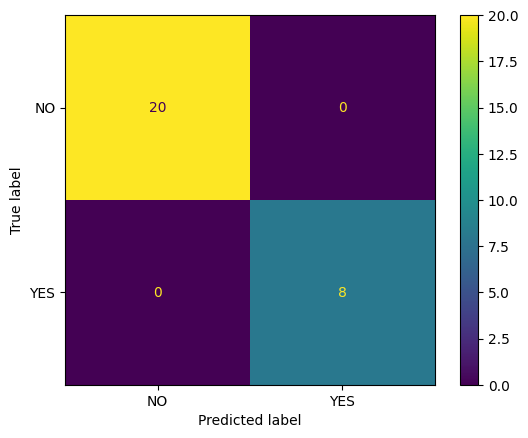

In [27]:
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)

print(cm)

ConfusionMatrixDisplay.from_predictions(y_test, preds)

In [14]:
importance_df = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": rf_layout.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
18,avg_text_block_area,0.097620
7,symbol_ratio,0.095780
24,image_area_ratio,0.065280
0,char_count,0.059524
20,total_image_area,0.055177
17,total_text_area,0.052337
21,avg_image_area,0.046079
25,largest_image_area_ratio,0.045932
22,largest_image_area,0.044387
13,chars_per_page_area,0.044249


In [15]:
model_path = MODEL_DIR / "ocr_decision_rf_layout_v1.joblib"
metadata_path = MODEL_DIR / "ocr_decision_rf_layout_v1_metadata.json"

joblib.dump(rf_layout, model_path)

metadata = {
    "model_name": "DocuMind OCR Decision Random Forest with Layout Features",
    "version": "v1_layout",
    "feature_columns": FEATURE_COLUMNS,
    "target": "ocr_required",
    "classes": list(rf_layout.classes_),
    "ocr_policy": OCR_POLICY,
    "label_name_map": LABEL_NAME_MAP
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model:", model_path)
print("Saved metadata:", metadata_path)

Saved model: C:\Users\rudra\Documents\VS Code Files\DocuMindAI\models\ocr_decision_rf_layout_v1.joblib
Saved metadata: C:\Users\rudra\Documents\VS Code Files\DocuMindAI\models\ocr_decision_rf_layout_v1_metadata.json


In [16]:
test_results = test_part.copy()

test_results["actual"] = y_test.values
test_results["predicted"] = preds

errors = test_results[
    test_results["actual"] != test_results["predicted"]
]

errors[
    [
        "document_name",
        "page_number",
        "actual",
        "predicted"
    ]
]

,document_name,page_number,actual,predicted
18,Community_Area_Analysis_A_C.pdf,2,YES,NO


In [17]:
review_df = test_part.copy()

review_df["actual"] = y_test.values
review_df["predicted"] = preds

errors = review_df[
    review_df["actual"] != review_df["predicted"]
]

errors[
    [
        "document_name",
        "page_number",
        "actual",
        "predicted"
    ]
]

,document_name,page_number,actual,predicted
18,Community_Area_Analysis_A_C.pdf,2,YES,NO
